#	Exercise 1: Compute autocorrelation

**Step 1**: Generate the Chain: Reuse your Metropolis-Hastings code from the previous assignment to generate a chain of 
 samples.

**Step 2**: Compute Errors:

*	Calculate the **standard deviation** $\sigma_{y}$ and the **naive error** $ \dfrac{\sigma_{y}}{\sqrt{N}} $.

*	Calculate the **autocovariance**
$$C_y(t)  =(1-\dfrac{t}{N})\bigl( \langle y_i y_{i+t} \rangle - \langle y_i \rangle  \langle y_{i+t}\rangle\bigr) \approx (1-\dfrac{t}{N})\langle (y_i - \overline{y})( y_{i+t} - \overline{y}) \rangle $$
*	Calculate the **integrated autocorelation time** 
$$ \tau_{int} = \dfrac{1}{2} + \sum_{t=1}^{N-1} \dfrac{C_y(t)}{C_y(0)}.$$
and the **corrected error**

$$ \sigma_{\overline{y}} = \dfrac{1}{\sqrt{N}} \sigma_{y} \times \sqrt{2\tau_{int}}$$
<!-- 
where $$ \tau_{int} = \dfrac{1}{2} + \sum_{t=1}^{N-1} \dfrac{C_y(t)}{C_y(0)}.$$

$$C_y(t)  =(1-\dfrac{t}{N})\bigl( \langle y_i y_{i+t} \rangle - \langle y_i \rangle  \langle y_{i+t}\rangle\bigr) \approx (1-\dfrac{t}{N})\langle (y_i - \overline{y})( y_{i+t} - \overline{y}) \rangle $$ -->
**Step 3** Visualization: Plot the normalized autocorrelation function $\rho(t)$ against lag t
$$\rho(t) = \dfrac{C_y(t)}{C_y(0)}$$

**Questions**:
+	What does it mean if $\rho(t)$ stays high for a long time (large t)?
+	If your chain has 100000 steps and $\tau_{int} = 50$, how many "independent" data points have you actually collected?
+	How would increasing the proposal step size in your Metropolis algorithm likely change the shape of the $C_y(t)$ plot?


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Reused Metropolis sampler from previous sheet
def gaussian_target(x, mu=0.0, sigma=1.0):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def metropolis_continuous(target, n_steps, step_size=1.0, x0=0.0):
    samples = np.empty(n_steps)
    x_cur = x0
    accepted = 0

    for t in range(n_steps):
        samples[t] = x_cur
        x_new = x_cur + step_size * np.random.randn()

        ratio = target(x_new) / target(x_cur)
        if np.random.rand() <= min(1.0, ratio):
            x_cur = x_new
            accepted += 1

    return samples, accepted / n_steps

# Generate chain
N = 100000
samples, acc_rate = metropolis_continuous(gaussian_target, N, step_size=1.0)

print("Chain length:", N)
print("Acceptance rate:", round(acc_rate,3))


Chain length: 100000
Acceptance rate: 0.705


We use the generated chain as our measured values $y_i$. Now we calculate naive error and then include autocorrelation.

In [5]:
# Standard deviation and naive error
sigma_y = np.std(samples, ddof=1)
naive_error = sigma_y / np.sqrt(N)

print("sigma_y =", round(sigma_y,5))
print("naive error =", round(naive_error,5))

# Autocovariance C_y(t)
max_lag = 100
mean_y = np.mean(samples)
centered = samples - mean_y

C = np.zeros(max_lag + 1)

for t in range(max_lag + 1):
    prod = centered[:N-t] * centered[t:]
    C[t] = (1 - t/N) * np.mean(prod)

rho = C / C[0]

# Integrated autocorrelation time
tau_int = 0.5 + np.sum(rho[1:])

corrected_error = sigma_y / np.sqrt(N) * np.sqrt(2 * tau_int)

print("tau_int =", round(tau_int,3))
print("corrected error =", round(corrected_error,5))

sigma_y = 1.00734
naive error = 0.00319
tau_int = 4.151
corrected error = 0.00918


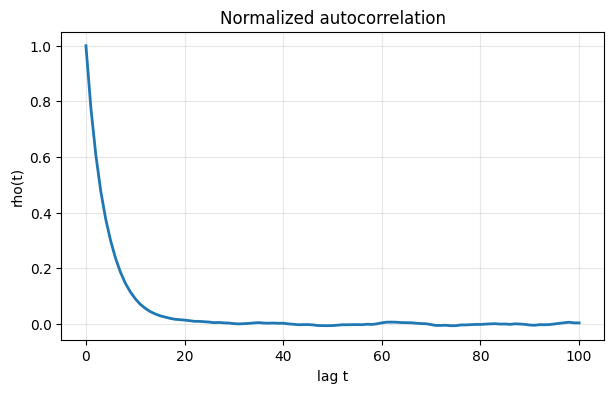

In [6]:
# Plot normalized autocorrelation
plt.figure(figsize=(7,4))
plt.plot(range(max_lag+1), rho, lw=2)
plt.xlabel("lag t")
plt.ylabel("rho(t)")
plt.title("Normalized autocorrelation")
plt.grid(alpha=0.3)
plt.show()

1. What does it mean if $\rho(t)$ stays high for a long time (large t)?
It means nearby samples are strongly related. The chain mixes slowly and we have fewer truly independent points.

2. If your chain has 100000 steps and $\tau_{int} = 50$, how many "independent" data points have you actually collected?
Effective independent data is approximately:

$$N_{\rm eff} = \frac{N}{2\,\tau_{\rm int}} = \frac{100\,000}{2 \times 50} = 1\,000$$

So only about **1000 independent samples**.

3. How would increasing the proposal step size in your Metropolis algorithm likely change the shape of the $C_y(t)$ plot?
Increasing proposal step size by too much would make more proposals rejected, and the chain would stay frozen at the same value for many steps.